In [25]:
import json

import matplotlib.pyplot as plt
from persiantools.digits import en_to_fa
import arabic_reshaper
from bidi.algorithm import get_display

In [2]:
ALGORITHMS = [
    "DYNAMOSA",
    "MOSA",
    "MIO",
    "RANDOM",
    "RANDOM_TEST_CASE_SEARCH",
    "RANDOM_TEST_SUITE_SEARCH",
    "WHOLE_SUITE",
]

info = {}
for algo in ALGORITHMS:
    info[algo] = {"time": {"t": [], "cov": []},
                  "no_time": {"t": [], "cov": []},
                  "mem": {"t": [], "cov": []},
                  "no_mem": {"t": [], "cov": []}
                 }
    for suffix in ["time", "no_time", "mem", "no_mem"]:
        with open(f"../results/refined/{algo}_{suffix}", 'r', encoding='utf-8') as f:
            first_t = None
            for line in f:
                d = json.loads(line)
                first_t = d["time"] if first_t is None else first_t
                info[algo][suffix]["t"].append(d["time"]-first_t)
                info[algo][suffix]["cov"].append(d["coverage"])
    print(f"Processed {algo}")

Processed DYNAMOSA
Processed MOSA
Processed MIO
Processed RANDOM
Processed RANDOM_TEST_CASE_SEARCH
Processed RANDOM_TEST_SUITE_SEARCH
Processed WHOLE_SUITE


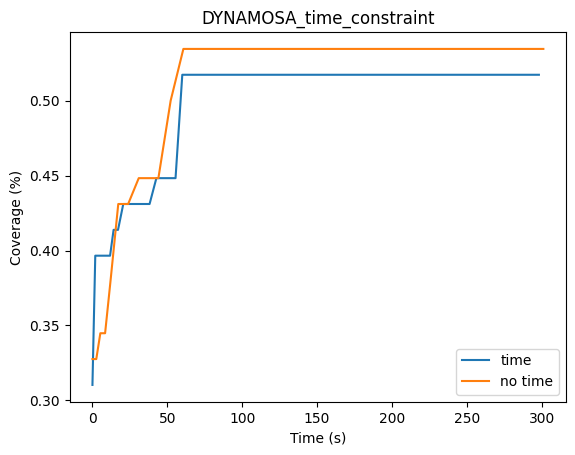

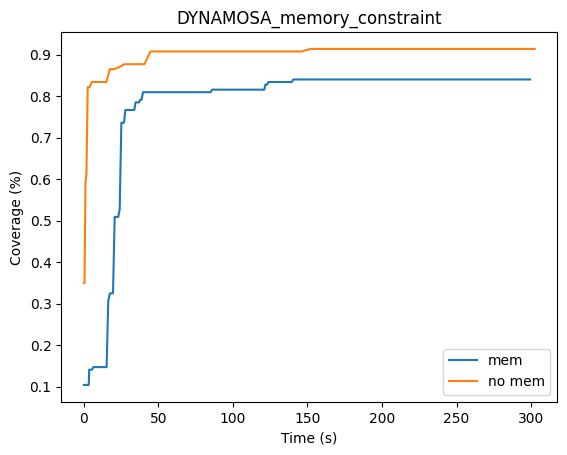

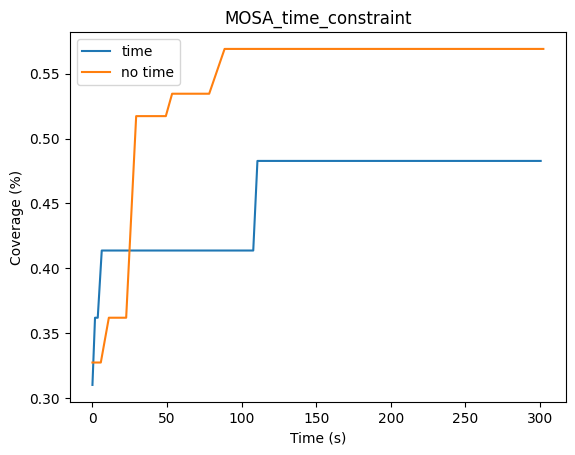

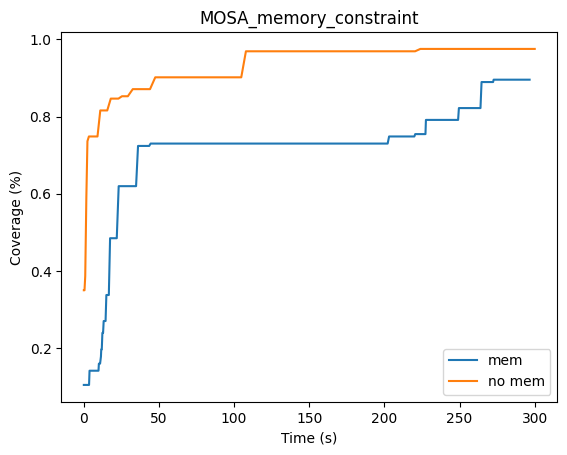

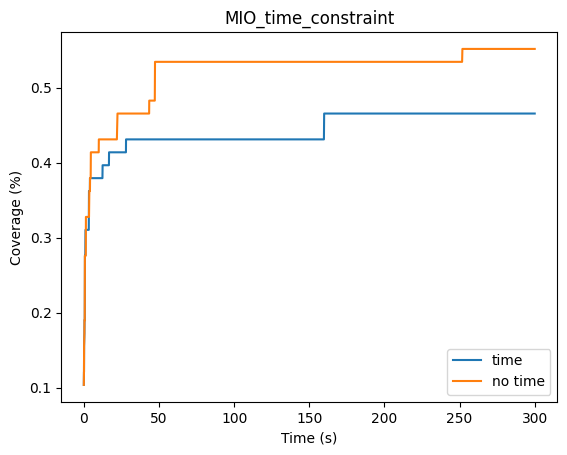

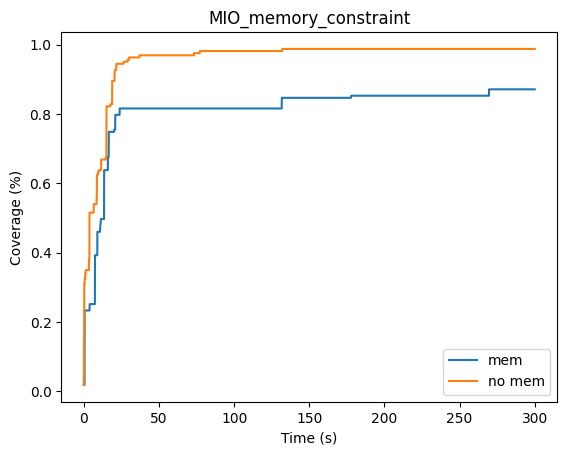

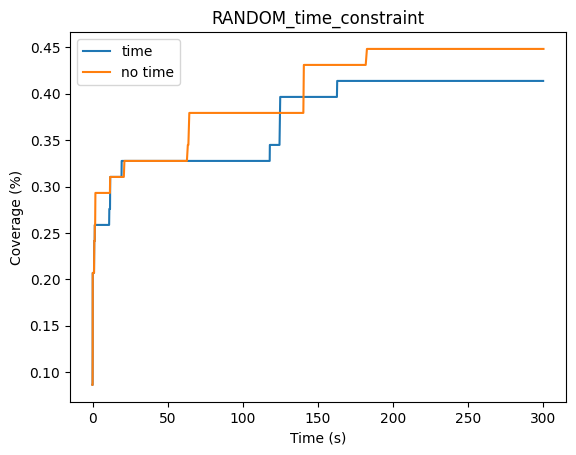

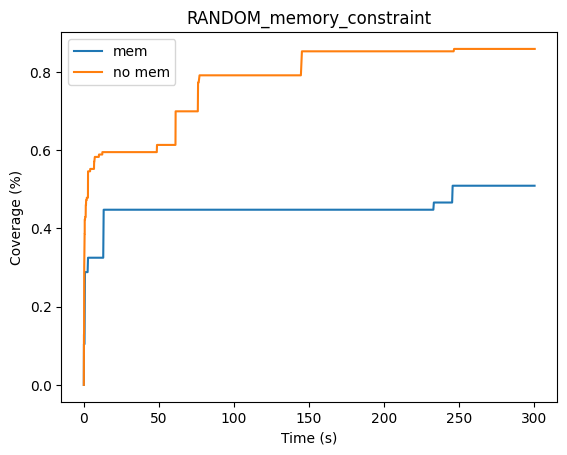

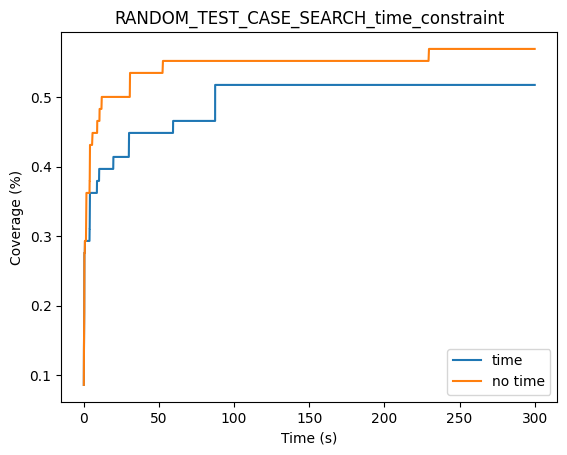

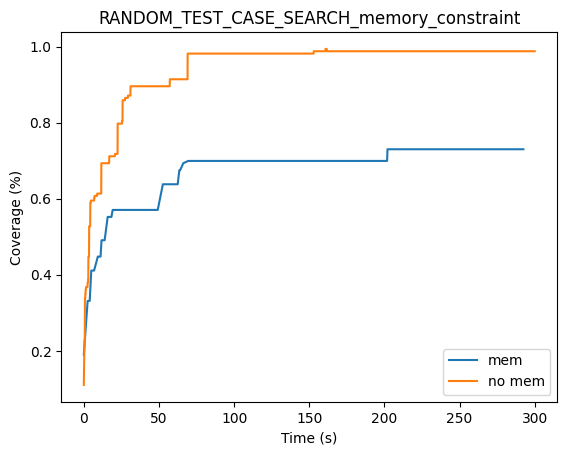

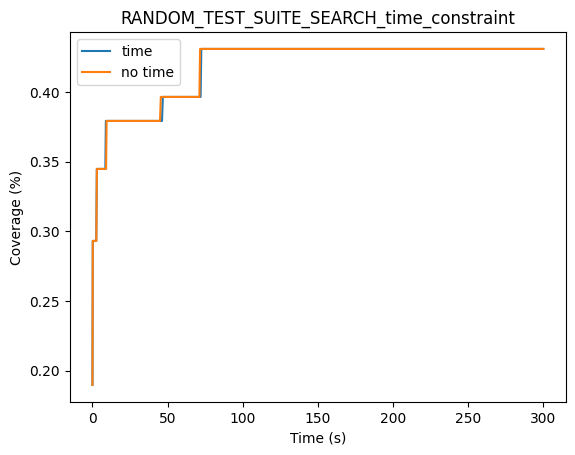

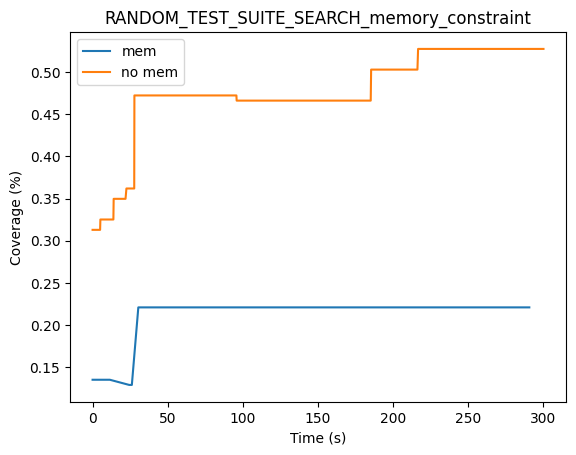

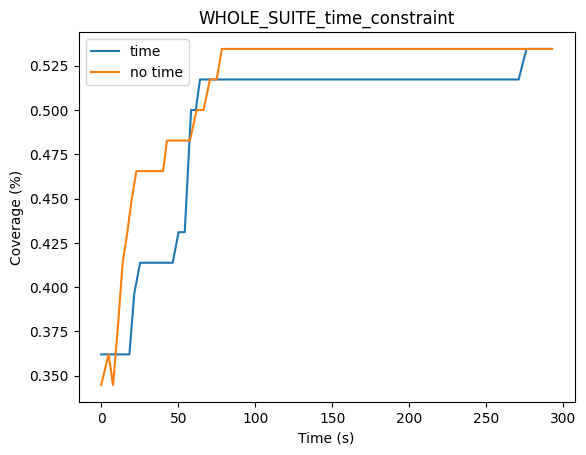

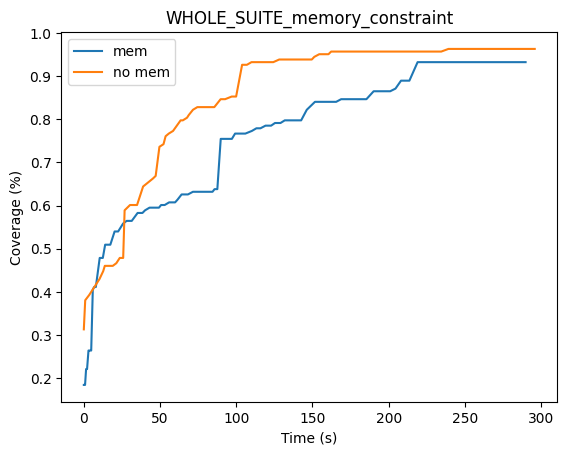

In [3]:
for algo in ALGORITHMS:
    title = f"{algo}_time_constraint"
    plt.title(title)
    plt.plot(info[algo]["time"]["t"], info[algo]["time"]["cov"], label="time")
    plt.plot(info[algo]["no_time"]["t"], info[algo]["no_time"]["cov"], label="no time")
    plt.xlabel("Time (s)")
    plt.ylabel("Coverage (%)")
    plt.legend()
    plt.savefig(f"../results/plots/{title}.jpeg")
    plt.show()

    title = f"{algo}_memory_constraint"
    plt.title(title)
    plt.plot(info[algo]["mem"]["t"], info[algo]["mem"]["cov"], label="mem")
    plt.plot(info[algo]["no_mem"]["t"], info[algo]["no_mem"]["cov"], label="no mem")
    plt.xlabel("Time (s)")
    plt.ylabel("Coverage (%)")
    plt.legend()
    plt.savefig(f"../results/plots/{title}.jpeg")
    plt.show()

/home/sepehr/university/MS/thesis/pynguin/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) Titr.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sepehr/university/MS/thesis/pynguin/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) Titr.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sepehr/university/MS/thesis/pynguin/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 89 (Y) missing from font(s) Titr.
  fig.canvas.print_figure(bytes_io, **kw)
/home/sepehr/university/MS/thesis/pynguin/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 88 (X) missing from font(s) Titr.
  fig.canvas.print_figure(bytes_io, **kw)


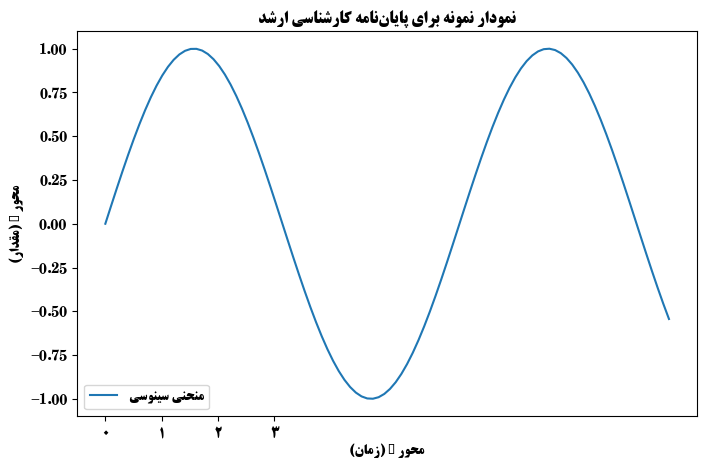

In [36]:
plt.rcParams["font.family"] = ["Titr"] # Or Nazli
plt.rcParams["font.size"] = 10
plt.rcParams["axes.unicode_minus"] = False  # Fix negative sign issues

def persian_text(text):
    reshaped_text = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped_text)
    return bidi_text

# Sample data
x = np.linspace(0, 10, 100)
y = np.sin(x)

# Create plot
plt.figure(figsize=(8, 5))

plt.plot(x, y, label=persian_text("منحنی سینوسی"))
x_labels = [0, 1, 2, 3]
x_labels_persian = [en_to_fa(str(x)) for x in x_labels]  # Convert to Persian digits
plt.xticks(x_labels, x_labels_persian)
plt.xlabel(persian_text("محور X (زمان)"))
plt.ylabel(persian_text("محور Y (مقدار)"))
plt.title(persian_text("نمودار نمونه برای پایان‌نامه کارشناسی ارشد"))
plt.legend()

# plt.grid(True)
plt.show()